In [ ]:
Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Create Dataset (3 Topics: Animals, Technology, Travel)
corpus = [
    "Dogs are loyal animals",
    "Cats are independent pets",
    "A puppy is a young dog",
    "Artificial intelligence is transforming technology",
    "Machine learning is a subset of AI",
    "Neural networks are powerful models",
    "Traveling to mountains is refreshing",
    "Beaches are popular tourist destinations",
    "I love exploring new cities",
    "Flights make travel faster"
]

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
#TF-IDF Vectorization
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(tfidf_matrix)
print("Shape of similarity matrix:", similarity_matrix.shape)
print(similarity_matrix)

Shape of similarity matrix: (10, 10)
[[1.         0.12720253 0.         0.         0.         0.11195513
  0.         0.11195513 0.         0.        ]
 [0.12720253 1.         0.         0.         0.         0.11195513
  0.         0.11195513 0.         0.        ]
 [0.         0.         1.         0.11195513 0.10113723 0.
  0.11195513 0.         0.         0.        ]
 [0.         0.         0.11195513 1.         0.0890142  0.
  0.09853539 0.         0.         0.        ]
 [0.         0.         0.10113723 0.0890142  1.         0.
  0.0890142  0.         0.         0.        ]
 [0.11195513 0.11195513 0.         0.         0.         1.
  0.         0.09853539 0.         0.        ]
 [0.         0.         0.11195513 0.09853539 0.0890142  0.
  1.         0.         0.         0.        ]
 [0.11195513 0.11195513 0.         0.         0.         0.09853539
  0.         1.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        

In [9]:
def find_similar(query, corpus, vectorizer, tfidf_matrix, top_k=3):
    query_vec = vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = similarities.argsort()[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append((corpus[idx], similarities[idx]))
    return results

In [11]:
queries = ["dog", "puppy", "airplane"]
for q in queries:
    print(f"\nQuery: {q}")
    results = find_similar(q, corpus, vectorizer, tfidf_matrix)
    for sentence, score in results:
        print(f"{sentence} --> Score: {score:.4f}")


Query: dog
A puppy is a young dog --> Score: 0.5394
Flights make travel faster --> Score: 0.0000
I love exploring new cities --> Score: 0.0000

Query: puppy
A puppy is a young dog --> Score: 0.5394
Flights make travel faster --> Score: 0.0000
I love exploring new cities --> Score: 0.0000

Query: airplane
Flights make travel faster --> Score: 0.0000
I love exploring new cities --> Score: 0.0000
Beaches are popular tourist destinations --> Score: 0.0000


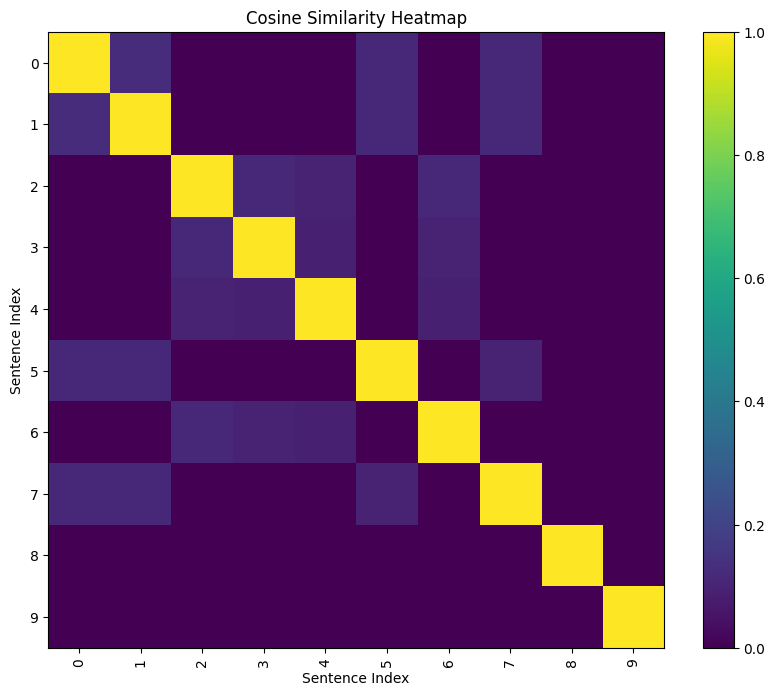

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix)
plt.colorbar()
plt.xticks(range(len(corpus)), range(len(corpus)), rotation=90)
plt.yticks(range(len(corpus)), range(len(corpus)))
plt.title("Cosine Similarity Heatmap")
plt.xlabel("Sentence Index")
plt.ylabel("Sentence Index")
plt.show()